<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK06_1_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.1 인공신경망의 한계와 딥러닝 출현

< 퍼셉트론 >
- 오늘날 딥러닝의 기원이되는 알고리즘
- 다수의 신호를 입력으로 받아 하나의 신호 출력 > 이 신호를 입력으로 받아 '흐른다/안흐른다(1 또는 0)'는 정보를 전달하는 원리로 작동

### AND 게이트

- 모든 입력이 1일 때 작동
- 하나라도 0을 갖는다면 작동을 멈춤

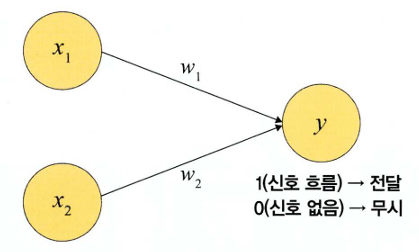

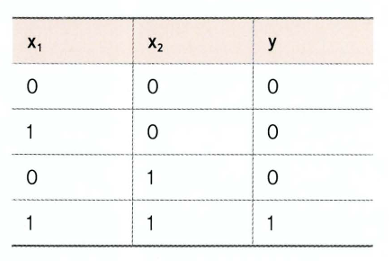

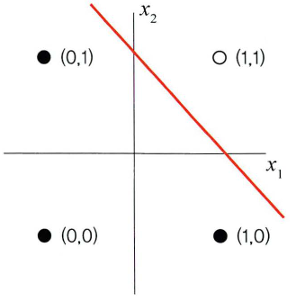

- 빨간 선 아래 = 출력이 0
- 빨간 선 위 = 출력이 1

> 즉, 직선 하나로 두 부류를 구분할 수 있음
> AND는 선형 분리(linearly separable)가 가능

### OR 게이트

- 입력에서 둘 중 하나만 1이거나 둘 다 1일 때 작동

> OR는 선형 분리(linearly separable)가 가능

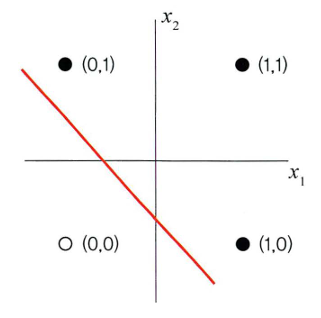

### XOR 게이트

- 배타적 논리합
- 입력 두 개 중 한 개만 1일 때 작동

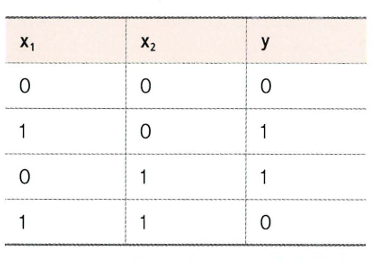

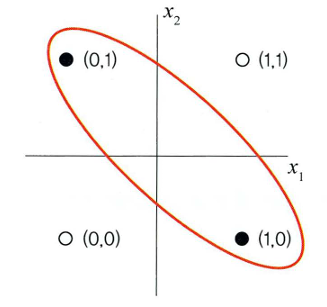

- 데이터가 비선형적으로 분리됨
- 제대로된 분류 곤란

> 단측 퍼셉트론에서는 AND, OR 연산에 대해서는 학습이 가능하지만, XOR에 대해서는 학습 불가능

< 극복하는 방법 >
- 입력층과 출력층 사이에 하나 이상의 중간층을 두어 비선형적으로 분리되는 데이터에 대해서도 학습이 가능하도록 **다층 퍼셉트론** 고안
  - 입력층과 출력층 사이에 은닉층이 여러개 있는 신경망 = **심층 신경망 = 딥러닝**

# 4.2 딥러닝 구조


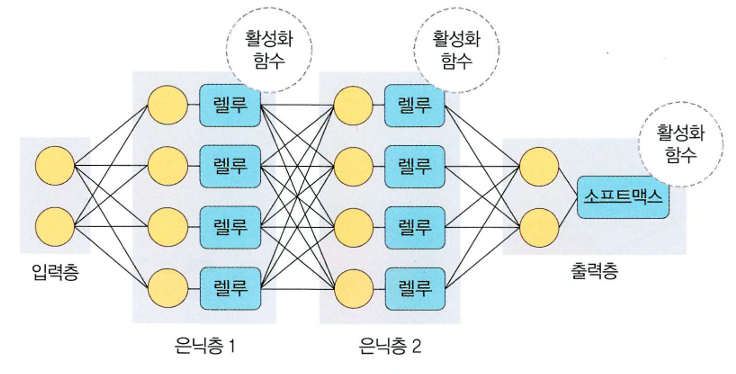

| 구분  | 구성 요소                       | 설명                                                           |
| --- | --------------------------- | ------------------------------------------------------------ |
| 층   | 입력층(input layer)            | 데이터를 받아들이는 층                                                 |
| 층   | 은닉층(hidden layer)           | 모든 입력 노드부터 입력 값을 받아 가중합을 계산하고, 이 값을 활성화 함수에 적용하여 출력층에 전달하는 층 |
| 층   | 출력층(output layer)           | 신경망의 최종 결과값이 포함된 층                                           |
| 가중치 | 가중치(weight)                 | 노드와 노드 간 연결 강도                                               |
| 가중치 | 바이어스(bias)                  | 가중합에 더해 주는 상수로, 하나의 뉴런에서 활성화 함수를 거쳐 최종적으로 출력되는 값을 조절하는 역할을 함 |
| 가중치 | 가중합(weighted sum), 전달 함수    | 가중치와 신호의 곱을 합한 것                                             |
| 함수  | 활성화 함수(activation function) | 신호를 입력받아 이를 적절히 처리하여 출력해 주는 함수                               |
| 함수  | 손실 함수(loss function)        | 가중치 학습을 위해 출력 함수의 결과와 실제 값 간의 오차를 측정하는 함수                    |


- 가중합 = 전달함수
  - 각 노드에 들어오는 신호에 가중치를 곱해 다음 노드로 전달
    - 이 값을 모두 더한 합계
  - 노드의 가중합이 계산되면 이 가중합을 다시 활성화 함수로 보내기에 전달 함수라고도 함

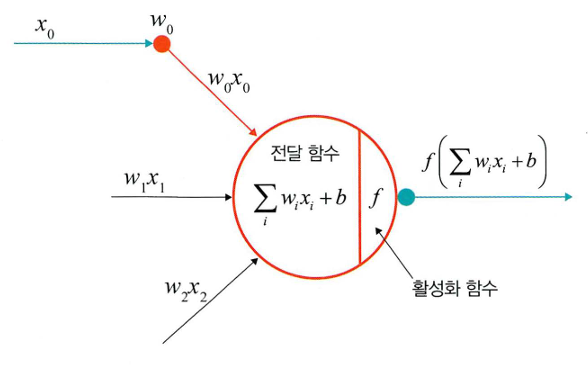

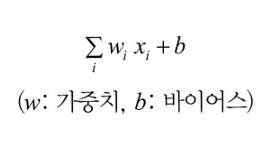

### 활성화 함수

- 전달 함수에서 전달받은 값을 출력할 때 일정 기준에 따라 출력 값을 변화시키는 비선형 함수
  - 시그모이드
  - 하이퍼볼릭 탄젠드
  - 렐루 등

**< 시그모이드 함수 >**

- 선형 함수의 결과를 0~1 사이에서 비선형 형태로 변형
- 로지스틱 회귀와 같은 분류 문제를 확률적으로 표현하는 데 사용
- 기울기 소멸 문제 발생
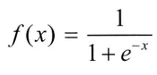

**< 하이퍼볼릭 탄젠트 함수 >**

- 선형 함수의 결과를 -1~1 사이에서 비선형 형태로 변형
- 시그모이드에서 결괏값의 평균이 0이 아닌 양수로 편향된 문제를 해결하는 데 사용
- 기울기 소멸 문제 여전히 발생


**< 렐루 함수 >**

- 입력이 음수일 때는 0 출력, 양수일 때는 x 출력
- 경사하강법에 영향을 주지 않아 학습 속도가 빠름
- 기울기 소멸 문제 X
- 일반적으로 은닉층에서 사용
- 하이퍼볼릭 탄젠트 함수 대비 학습 속도 6배 빠름
- 음수값을 입력받으면 항상 0을 출력하기에 학습 능력 감소
> 극복을 위해 리키 렐루 함수 사용

**< 리키 렐루 함수 >**

- 입력값이 음수면 0.001처럼 매우 작은 수 반환


**< 소프트맥스 함수 >**

- 입력값을 0~1 사이에 출력되도록 정규화하여 출력 값들의 총 합이 항상 1이 되도록 함
- 출력 노드의 활성화 함수로 많이 사용됨

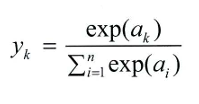

- n = 출력층의 뉴런 개수
- y_k= k번째 출력

In [1]:
import torch

In [2]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)   # 은닉층
        self.relu = torch.nn.ReLU(inplace=True)
        self.out = torch.nn.Linear(n_hidden, n_output)       # 출력층
        self.softmax = torch.nn.Softmax(dim=n_output)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)      # 은닉층을 위한 렐루 활성화 함수
        x = self.out(x)
        x = self.softmax(x)   # 출력층을 위한 소프트맥스 활성화 함수
        return x

### 손실 함수

- 경사하강법 : 학습률과 손실 함수의 순간 기울기를 이용하여 가중치를 업데이트
  - 즉, 미분의 기울기를 이용하여 오차를 비교하고 최소화하는 방향으로 이동시키는 방법
  - dL / dw : L: 손실 함수, w: 가중치
    - 가중치를 조금 바꿨을 때 손실이 얼마나 변하는가
  - 이때, 오차를 구하는 방법 = 손실 함수
> 학습을 통해 얻은 데이터의 추정치가 실제 데이터와 얼마나 차이가 나는지 평가
  - 평균 제곱 오차 MSE
  - 크로스 엔트로피 오차

< MSE >

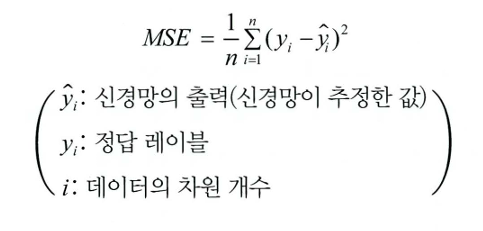



```
import torch

loss_fn = torch.nn.MSELoss(reduction='sum')
y_pred = model(x)
loss = loss_fn(y_pred, y)
```



< 크로스 엔트로피 오차 >

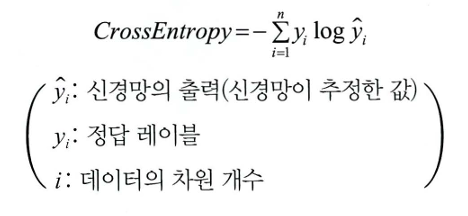

- 분류 문제에서 원핫 인코딩을 했을 경우 사용 가능
- MSE와 시그모이드 활성화 함수를 결합하여 사용하면 시그모이드 특성으로 기울기가 매끄럽지 못한 경우 발생 + 학습 속도 매우 늦음
- 두 개의 확률 분포 차이를 이용하기에 시그모이드 영향을 덜 받음 + 평균 제곱 오차보다 학습 속도가 빠름



```
import torch
import torch.nn as nn

loss = nn.CrossEntropyLoss()
input = torch.randn(3, 5, requires_grad=True)      # 평균이 0 표준편차가 1인 가우시안 정규분포를 이용해 숫자를 생성
target = torch.empty(3, dtype=torch.long).random_(5)   # dtype=torch.float32 형태의 텐서를 만들고, 이를 랜덤한 값으로 채움
output = loss(input, target)
output.backward()
```



## 딥러닝 학습

- 순전파(feedforward)
  - 입력 데이터가 입력층에서 은닉층, 출력층으로 전달되며 예측값을 계산하는 과정
  - 각 뉴런은 이전 층의 출력값에 가중합과 활성화 함수를 적용하여 다음 층으로 전달
  - 모든 층의 계산이 완료되면 최종적으로 출력층에서 예측값이 생성됨
- 손실 함수(loss function)
  - 예측값과 실제값의 차이, 즉 손실(오차)을 계산하는 함수
  - 손실값은 0에 가까울수록 바람직한 상태
  - 모델 학습의 목적 = 손실값이 작아지도록 가중치를 조정하는 것
- 역전파(backpropagation)
  - 계산된 손실 정보를 출력층 > 은닉층 > 입력층 방향으로 거꾸로 전달하는 과정
  - 역전파 과정에서 각 뉴런은 출력 결과에 기여한 정도에 따라 서로 다른 값으로 반영
  - 수학적으로는 손실을 각 가중치에 대해 미분하여 변화량을 계산
  - 계산된 변화량을 이용하여 기존 가중치를 수정함
수정된 가중치는 다시 다음 순전파 계산에 사용됨

## 딥러닝의 문제점과 해결방안

- 딥러닝의 핵심은 활성화 함수가 적용된 여러 은닉층을 결합하여 비선형 영역을 표현하는 것
- 활성화 함수가 적용된 은닉층 개수가 많을수록 데이터 분류가 잘 되고 있는 것
- But, 훈련 데이터를 과하게 학습하면 예측값과 실제값 차이인 오차는 감소하지만, 검증 데이터에 대해서는 오차가 증가할 수 있음
  - 과적합
- 과적합 해결법
  - drop-out
    - 임의로 일부 노드를 학습에서 제외

In [3]:
class DropoutModel(torch.nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.layer1 = torch.nn.Linear(784, 1200)
        # 50%의 노드를 무작위로 선택하여 사용하지 않겠다는 의미
        self.dropout1 = torch.nn.Dropout(0.5)
        self.layer2 = torch.nn.Linear(1200, 1200)
        self.dropout2 = torch.nn.Dropout(0.5)
        self.layer3 = torch.nn.Linear(1200, 10)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        return self.layer3(x)

- 기울기 소멸 문제

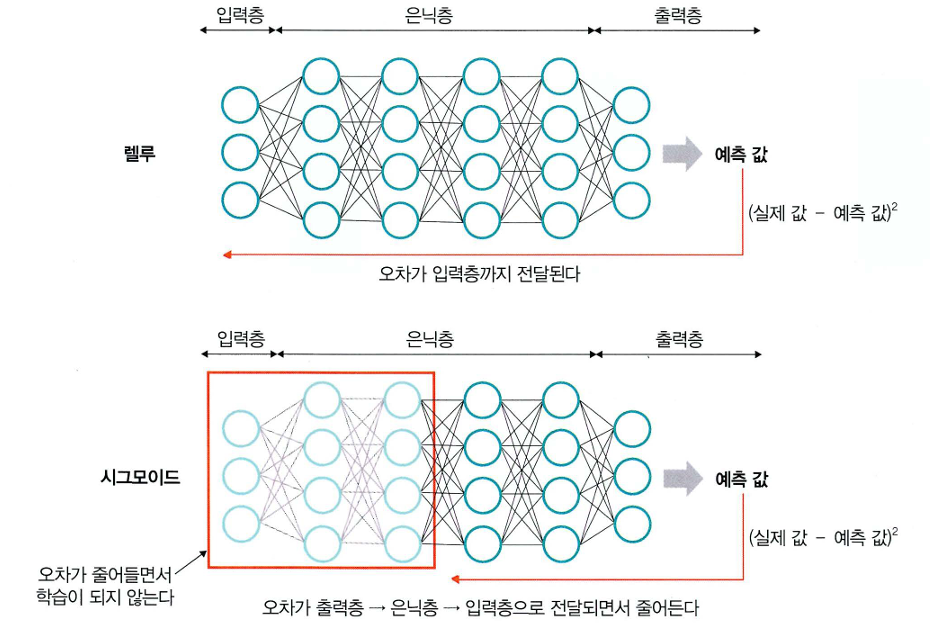

- 성능 worse

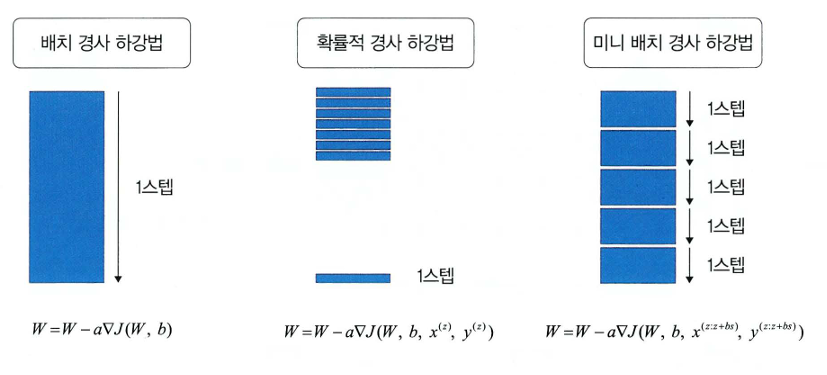

- W: 현재 가중치
- α: 학습률
- J: 손실 함수
- ∇J: 손실 함수의 기울기
- x(z:z+bs): z번째부터 z+bs번째까지의 데이터 묶음
- bs: batch size, 배치 크기



```
class CustomDataset(Dataset):
    def __init__(self):
        self.x_data = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
        self.y_data = [[12], [18], [11]]   # 3개의 쌍 DATA

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.x_data[idx])
        y = torch.FloatTensor(self.y_data[idx])
        return x, y


dataset = CustomDataset()
dataloader = DataLoader(
    dataset,        # 데이터셋
    batch_size=2,   # 미니 배치 크기로 2의 제곱수를 사용하겠다는 의미
    shuffle=True,   # 데이터를 불러올 때마다 랜덤으로 섞어서 가져옴
)
```



# 4.3 딥러닝 알고리즘

- 심층 신경망을 사용
- 목적에 따라 다음으로 분류
  - 합성곱
  - 순환
  - 제한된 볼츠만 머신
  - 심층 신뢰 신경망

## 합성곱 신경망

- 합성곱층, 풀링층을 포함하는 이미지 처리 성능이 좋은 인공 신경망 알고리즘
- 각 층의 입출력 형상을 유지
- 이미지의 공간 정보를 유지하면서 인접 이미지와 차이가 있는 특징을 효과적으로 인식
- 복수 필터로 이미지의 특징을 추출하고 학습
- 추출한 이미지의 특정을 모으고 강화하는 풀링층 존재
- 필터를 공유 파라미터로 시용하기 때문에 일반 인공 신경망과 비교하여 학습 파라미터가 매우 적음

## 순환 신경망

- 시계열 데이터와 같은 시간의 흐름에 따라 변화하는 데이터를 학습하기 위한 인공 신경망
> 이전의 결과와 현재 결과과 연관이 있다는 의미
- 시간성을 가진 데이터가 많음
- 시간성 정보를 이용하여 데이터 특징을 잘 다룸
- 시간에 따라 내용이 변하기에 데이터는 동적, 길이는 가변

## 제한된 볼츠만 머신

- 가시층과 은닉층으로 구성

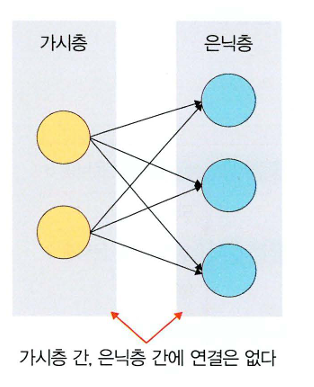

- 치원 감소， 분류， 선형 회귀 분석， 협업 필터링(collaborative filteri폐， 특성 값 학습, 주제 모델링에 사용
- 기울기 소멸 문제를 해결하기 위해 사전 학습 용도로 활용 가능
- 심층 신뢰 신경망(DBN)의 요소로 활용

## 심층 신뢰 신경망

- 사전 훈련된 제한된 볼츠만 머신을 층층이 쌓아 올린 구조
- 레이블이 없는 데이터에 대한 비지도 학습 가능

< 절차 >
1.  가시층과 은닉층 1에 제한된 볼츠만 머신 사전 훈련
2.   첫 번째 층 입력 데이터와 파라미터를 고정하여 두 번째 층 제한된 볼츠만 머신을 사전 훈련
3.  원하는 층 개수만큼 제한된 볼츠만 머신을 쌓아 올려 전체 DBN을 완성

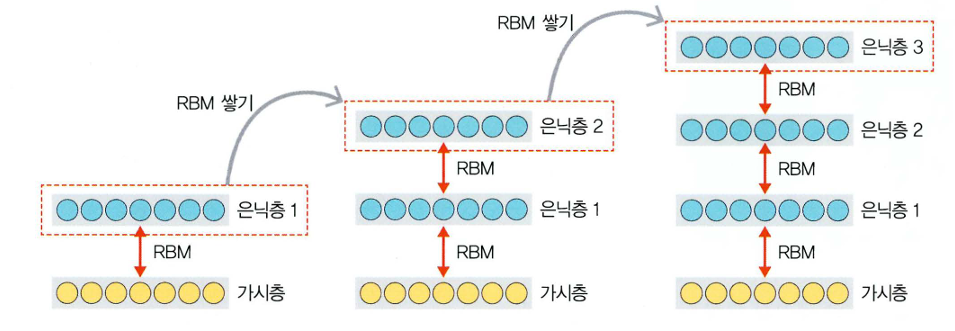